# Reconstruction quality — `MotionConvAutoencoder`

Loads the newest checkpoint under `runs/`, runs it over validation windows, and reports:

- per-channel and per-DoF reconstruction error in normalized units,
- R² (fraction of variance explained) per channel / per DoF,
- ground truth vs reconstruction overlays,
- error distributions.

Channels are `[sin, cos, vel, acc, tau]`. Only `vel, acc, tau` (indices 2, 3, 4) are in the training loss;
`sin/cos` are passed through unnormalized, so they are reported separately.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch as t
from omegaconf import OmegaConf

sys.path.insert(0, "../src")

from sometria.dataset import MotionDataModule
from sometria.model import MotionConvAutoencoder
from sometria.preprocess import _load_human_definition, feature_dofs

ROOT = Path("..")
RUNS = ROOT / "runs"
CHANNELS = ["sin", "cos", "vel", "acc", "tau"]
MAX_BATCHES = 40      # validation batches to score

## Load checkpoint + data

In [ ]:
config = OmegaConf.load(ROOT / "config/experiment.yaml")
config.dataloader.root = str(ROOT / config.dataloader.root)
config.dataloader.num_workers = 0

# newest checkpoint wins; point CKPT somewhere else to compare runs
CKPT = "../runs/conv_autoencoder_smoke/lightning_logs/version_2/checkpoints/epoch=9-step=15900.ckpt" #max(RUNS.rglob("*.ckpt"), key=lambda p: p.stat().st_mtime)
print("checkpoint:", CKPT)

model = MotionConvAutoencoder.load_from_checkpoint(CKPT, map_location="cpu").eval()
device = "cuda" if t.cuda.is_available() else "cpu"
model = model.to(device)

datamodule = MotionDataModule(config)
datamodule.setup("fit")
val_loader = datamodule.val_dataloader()

dof_names = feature_dofs(_load_human_definition(ROOT / "config/human.yaml"))
mean = datamodule.val_dataset.mean          # (1, dofs, feats)
std = datamodule.val_dataset.std
norm_mask = datamodule.val_dataset.normalization_mask

print(f"val samples: {len(datamodule.val_dataset)}, dofs: {len(dof_names)}, loss channels:",
      [CHANNELS[i] for i in t.nonzero(model.loss_channel_mask).flatten().tolist()])

checkpoint: ../runs/conv_autoencoder_smoke/lightning_logs/version_2/checkpoints/last.ckpt
val samples: 2006, dofs: 43, loss channels: ['vel', 'acc', 'tau']


## Run the model over validation windows

In [3]:
@t.no_grad()
def collect(loader, max_batches):
    targets, predictions, valids, ids = [], [], [], []
    for i, batch in enumerate(loader):
        if i >= max_batches:
            break
        features = batch["features"].to(device)
        prediction = model(features)
        targets.append(features.cpu())
        predictions.append(prediction.cpu())
        valids.append(batch["valid"])
        ids.extend(batch["sample_id"])
    return t.cat(targets), t.cat(predictions), t.cat(valids), ids

target, prediction, valid, sample_ids = collect(val_loader, MAX_BATCHES)
print("collected", target.shape, "windows, valid frames:", int(valid.sum()))

collected torch.Size([320, 256, 43, 5]) windows, valid frames: 75329


## Per-channel error

Everything below is computed on valid frames only (padded short motions are excluded), in
normalized units — for `vel/acc/tau` that means "in standard deviations of the training set",
so an RMSE of 1.0 is as good as predicting the mean.

`R² = 1 - MSE / Var(target)`: 1.0 is perfect, 0.0 is no better than the constant mean,
negative is worse than the mean.

In [4]:
# (frames, dofs, channels) — flatten batch/time, keep only valid frames
flat_target = target[valid]
flat_prediction = prediction[valid]
error = flat_prediction - flat_target

def stats(err, tgt, dim):
    mse = err.square().mean(dim=dim)
    var = tgt.var(dim=dim, unbiased=False)
    return mse, mse.sqrt(), 1 - mse / var

channel_mse, channel_rmse, channel_r2 = stats(error, flat_target, dim=(0, 1))
in_loss = model.loss_channel_mask.cpu()
loss_channel_ids = t.nonzero(in_loss).flatten()

print(f"{'channel':<8}{'RMSE':>10}{'R2':>10}{'target std':>13}   in loss")
for i, name in enumerate(CHANNELS):
    print(f"{name:<8}{channel_rmse[i]:>10.4f}{channel_r2[i]:>10.4f}"
          f"{flat_target[..., i].std():>13.4f}   {'yes' if in_loss[i] else 'no'}")

channel       RMSE        R2   target std   in loss
sin         1.1558   -7.1853       0.4040   no
cos         1.5545  -47.3792       0.2235   no
vel         0.3483    0.8978       1.0896   yes
acc         0.3344    0.9053       1.0864   yes
tau         0.4970    0.6856       0.8864   yes


### Per-DoF, per-channel R²

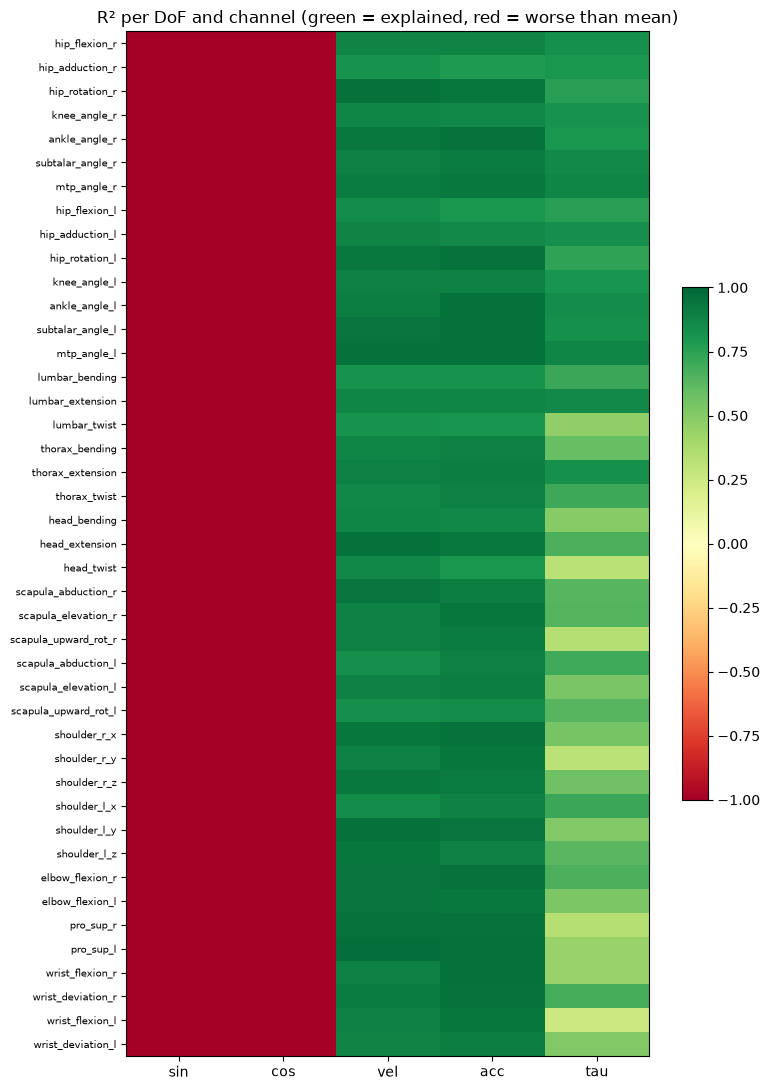

In [5]:
dof_mse, dof_rmse, dof_r2 = stats(error, flat_target, dim=0)   # (dofs, channels)
dof_var = flat_target.var(dim=0, unbiased=False)

# R² is unusable where the target barely moves across the sampled windows: the denominator
# collapses and a small absolute error reads as a huge negative number. Blank those out rather
# than believing them. Raise MAX_BATCHES if too many DoFs get dropped.
low_variance = dof_var < 0.05
dof_r2 = dof_r2.masked_fill(low_variance, float("nan"))
print(f"{int(low_variance[:, loss_channel_ids].sum())} of {low_variance[:, loss_channel_ids].numel()} "
      "DoF/channel cells dropped for near-zero target variance")

fig, ax = plt.subplots(figsize=(8, 11))
cmap = plt.get_cmap("RdYlGn").copy()
cmap.set_bad("lightgray")
image = ax.imshow(dof_r2.numpy(), aspect="auto", cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(CHANNELS)), CHANNELS)
ax.set_yticks(range(len(dof_names)), dof_names, fontsize=7)
ax.set_title("R² per DoF and channel (gray = too little target variance to score)")
fig.colorbar(image, ax=ax, shrink=0.5)
fig.tight_layout()
plt.show()


In [6]:
mean_r2 = dof_r2[:, loss_channel_ids].nanmean(dim=1)
# normalized MSE needs no per-DoF denominator, so it stays meaningful for quiet DoFs too
mean_nmse = dof_mse[:, loss_channel_ids].mean(dim=1)

scored = t.nonzero(~mean_r2.isnan()).flatten()
order = scored[mean_r2[scored].argsort(descending=True)]

def show(indices, title):
    print(f"{title:<34}{'R²':>8}{'norm MSE':>11}")
    for i in indices:
        print(f"  {dof_names[i]:<32}{mean_r2[i]:>8.3f}{mean_nmse[i]:>11.3f}")

show(order[:10], "best 10 DoFs (vel/acc/tau)")
show(order.flip(0)[:10], "worst 10 DoFs (vel/acc/tau)")


best 10 DoFs (mean R² over vel/acc/tau)
  mtp_angle_l                0.929
  subtalar_angle_l           0.909
  mtp_angle_r                0.902
  ankle_angle_l              0.900
  ankle_angle_r              0.893
  subtalar_angle_r           0.889
  hip_rotation_r             0.884
  thorax_extension           0.873
  hip_rotation_l             0.870
  lumbar_extension           0.865
worst 10 DoFs
  head_twist                 0.663
  wrist_flexion_l            0.692
  lumbar_twist               0.699
  shoulder_r_y               0.715
  scapula_upward_rot_r       0.716
  head_bending               0.744
  pro_sup_r                  0.746
  wrist_deviation_l          0.762
  wrist_flexion_r            0.764
  scapula_upward_rot_l       0.774


## Reconstruction overlays

One validation window, ground truth vs reconstruction. `WINDOW` picks which window of the
collected batch; `SHOW_DOFS` picks which DoFs to draw.

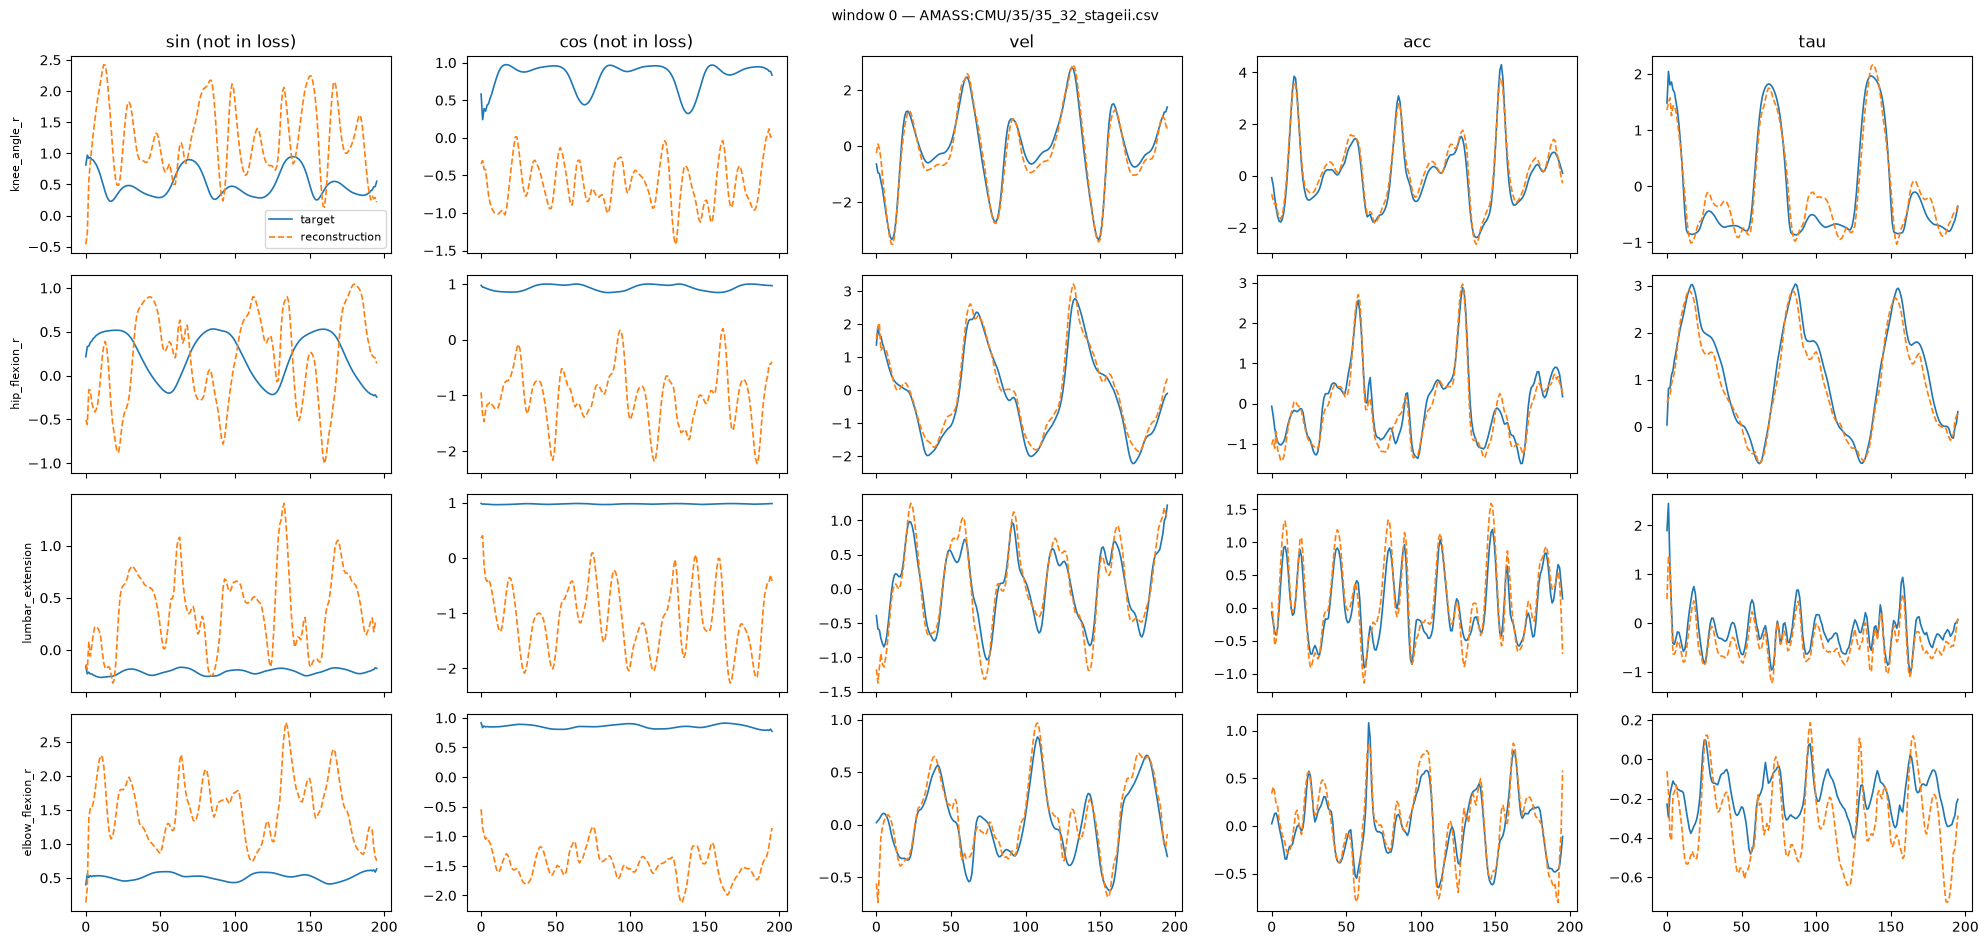

In [7]:
WINDOW = 0
SHOW_DOFS = ["knee_angle_r", "hip_flexion_r", "lumbar_extension", "elbow_flexion_r"]

frames = valid[WINDOW]
time_axis = np.arange(int(frames.sum()))

fig, axes = plt.subplots(len(SHOW_DOFS), len(CHANNELS), figsize=(20, 2.4 * len(SHOW_DOFS)),
                         sharex=True, squeeze=False)
for row, dof in enumerate(SHOW_DOFS):
    d = dof_names.index(dof)
    for col, channel in enumerate(CHANNELS):
        ax = axes[row][col]
        ax.plot(time_axis, target[WINDOW, frames, d, col], lw=1.2, label="target")
        ax.plot(time_axis, prediction[WINDOW, frames, d, col], lw=1.2, ls="--", label="reconstruction")
        if row == 0:
            ax.set_title(f"{channel}{'' if in_loss[col] else ' (not in loss)'}")
        if col == 0:
            ax.set_ylabel(dof, fontsize=8)
axes[0][0].legend(fontsize=8)
fig.suptitle(f"window {WINDOW} — {sample_ids[WINDOW]}", fontsize=10)
fig.tight_layout()
plt.show()

### Same overlay in physical units

Undo the normalization so `vel/acc/tau` are back in the units the preprocessing produced
(note: the derivative channels went through a signed log upstream, so these are log-compressed
units, not raw rad/s).

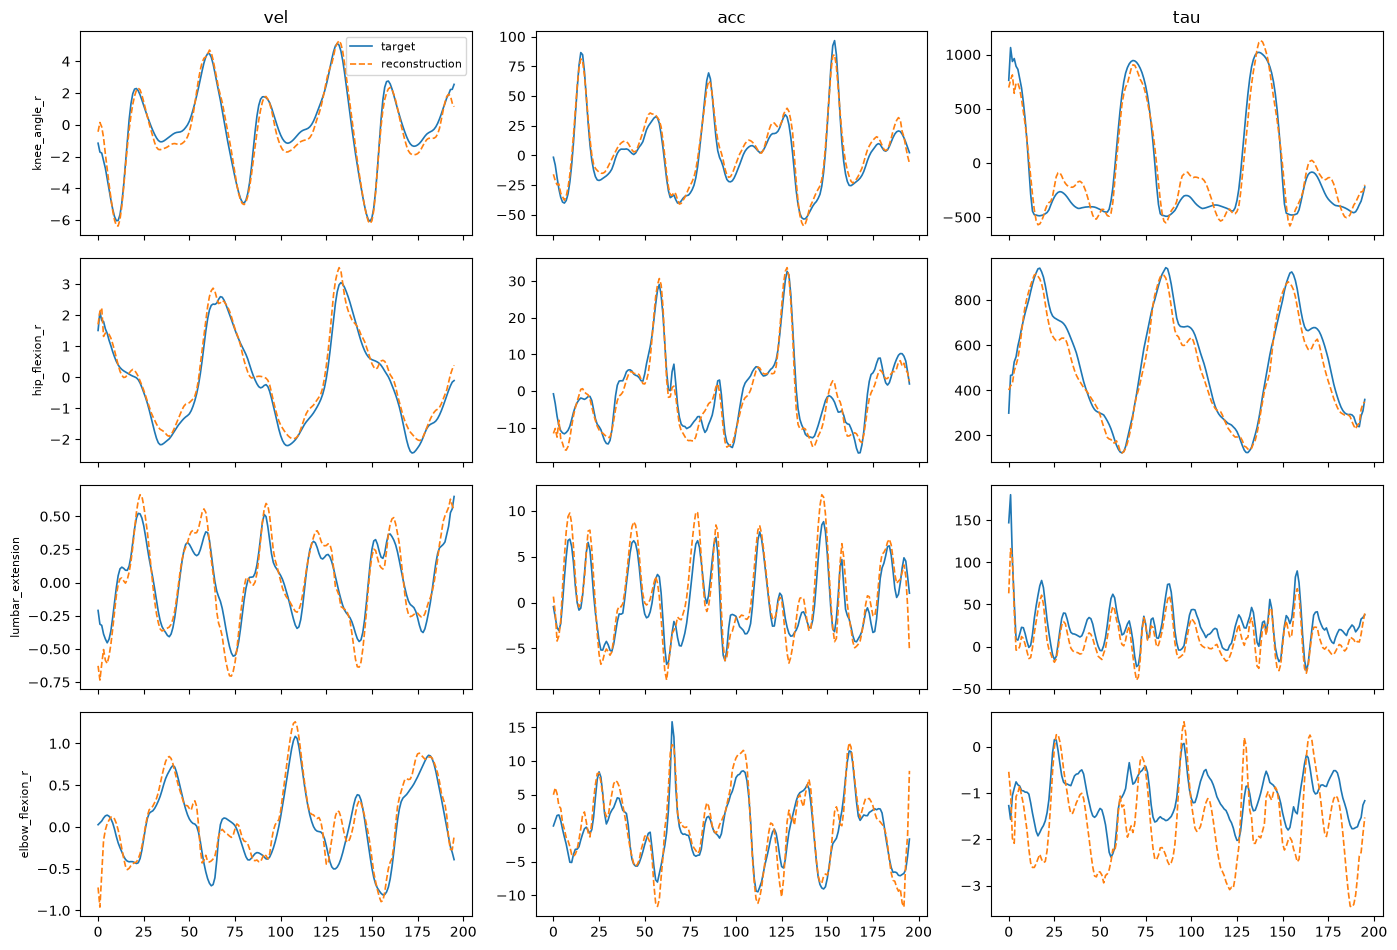

In [8]:
def denormalize(x):
    return t.where(norm_mask, x * std + mean, x)

denorm_target = denormalize(target[WINDOW][frames])
denorm_prediction = denormalize(prediction[WINDOW][frames])

fig, axes = plt.subplots(len(SHOW_DOFS), len(loss_channel_ids), figsize=(14, 2.4 * len(SHOW_DOFS)),
                         sharex=True, squeeze=False)
for row, dof in enumerate(SHOW_DOFS):
    d = dof_names.index(dof)
    for col, c in enumerate(loss_channel_ids.tolist()):
        ax = axes[row][col]
        ax.plot(time_axis, denorm_target[:, d, c], lw=1.2, label="target")
        ax.plot(time_axis, denorm_prediction[:, d, c], lw=1.2, ls="--", label="reconstruction")
        if row == 0:
            ax.set_title(CHANNELS[c])
        if col == 0:
            ax.set_ylabel(dof, fontsize=8)
axes[0][0].legend(fontsize=8)
fig.tight_layout()
plt.show()

## Error distributions and calibration

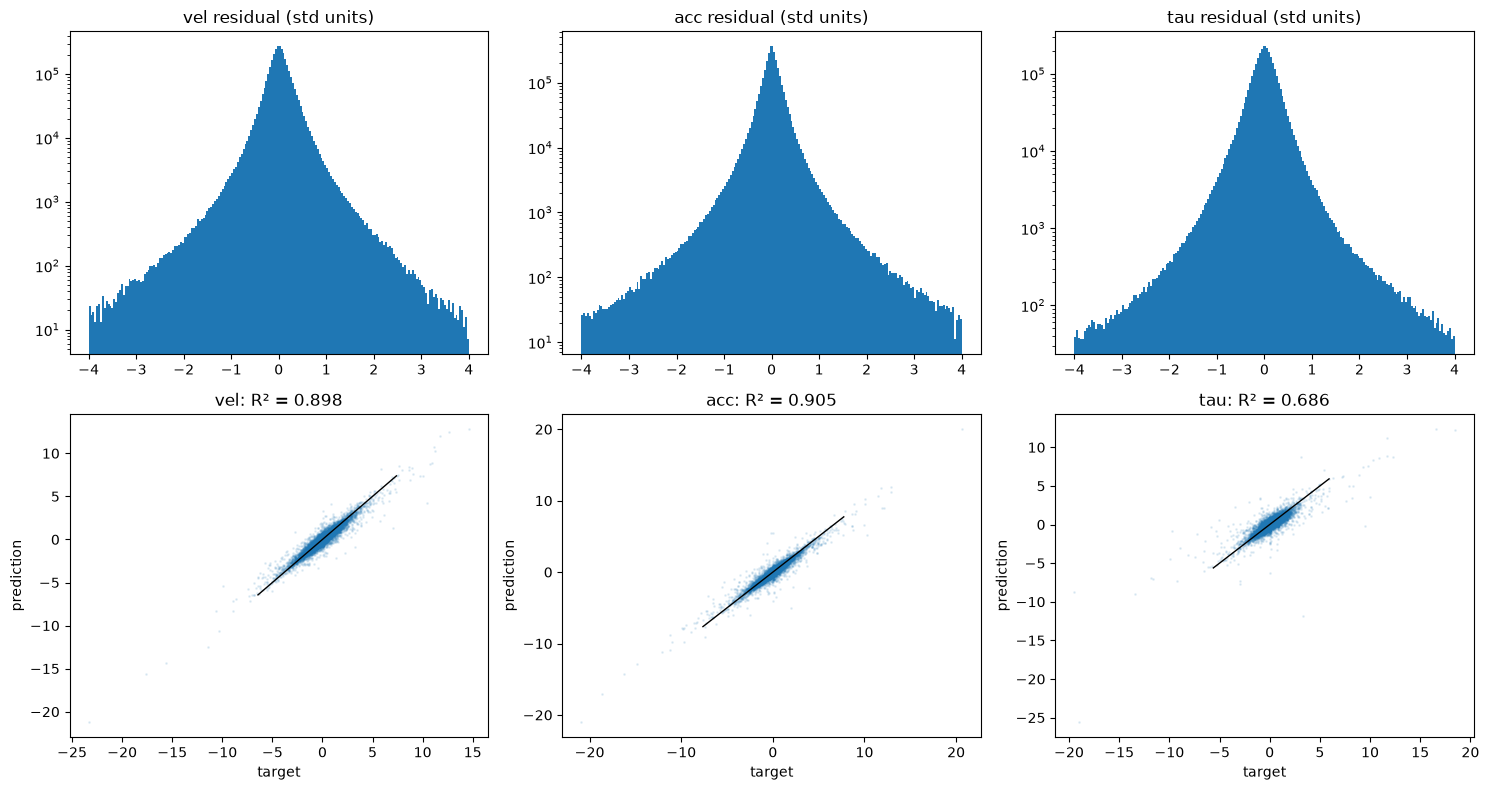

In [9]:
fig, axes = plt.subplots(2, len(loss_channel_ids), figsize=(5 * len(loss_channel_ids), 8))
for col, c in enumerate(loss_channel_ids.tolist()):
    e = error[..., c].flatten().numpy()
    axes[0][col].hist(e, bins=200, range=(-4, 4), log=True)
    axes[0][col].set_title(f"{CHANNELS[c]} residual (std units)")

    # subsample: scatter of every point is pointless and slow
    idx = np.random.default_rng(0).choice(flat_target[..., c].numel(), size=20000, replace=False)
    tgt = flat_target[..., c].flatten()[idx].numpy()
    pred = flat_prediction[..., c].flatten()[idx].numpy()
    axes[1][col].scatter(tgt, pred, s=1, alpha=0.1)
    lims = (np.percentile(tgt, 0.1), np.percentile(tgt, 99.9))
    axes[1][col].plot(lims, lims, color="k", lw=1)
    axes[1][col].set_xlabel("target"); axes[1][col].set_ylabel("prediction")
    axes[1][col].set_title(f"{CHANNELS[c]}: R² = {channel_r2[c]:.3f}")
fig.tight_layout()
plt.show()

## Baselines

The number that matters: is the model beating the trivial predictors? `mean` predicts the
per-channel training mean (0 in normalized space); `copy-last-frame` (persistence) is what a
model exploiting only temporal smoothness would get.

In [10]:
zero_mse = flat_target.square().mean(dim=(0, 1))

# persistence within each window, on valid frames
shifted = target[:, :-1]
actual = target[:, 1:]
step_valid = valid[:, 1:] & valid[:, :-1]
persistence_mse = (actual[step_valid] - shifted[step_valid]).square().mean(dim=0).mean(dim=0)

print(f"{'channel':<8}{'model MSE':>12}{'mean MSE':>12}{'persistence':>14}")
for i, name in enumerate(CHANNELS):
    marker = "" if in_loss[i] else "   (not in loss)"
    print(f"{name:<8}{channel_mse[i]:>12.4f}{zero_mse[i]:>12.4f}{persistence_mse[i]:>14.4f}{marker}")

channel    model MSE    mean MSE   persistence
sin           1.3359      0.1643        0.0002   (not in loss)
cos           2.4165      0.8357        0.0001   (not in loss)
vel           0.1213      1.1872        0.0743
acc           0.1118      1.1803        0.2138
tau           0.2470      0.7859        0.0829


## Training curves

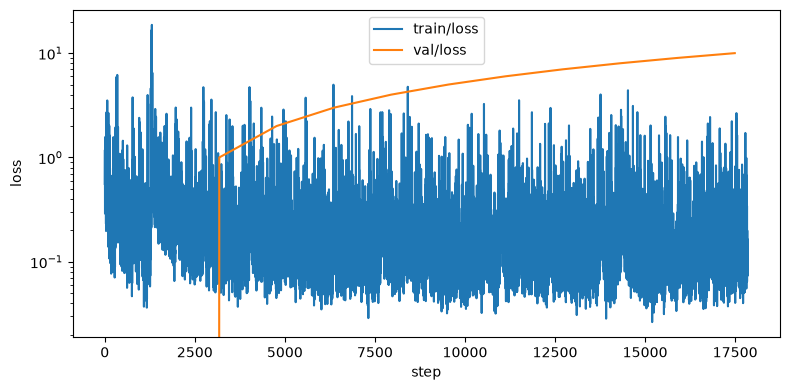

In [11]:
import polars as pl

metrics = pl.read_csv(Path(CKPT).parents[1] / "metrics.csv")
fig, ax = plt.subplots(figsize=(8, 4))
for column in ("train/loss", "val/loss"):
    if column in metrics.columns:
        series = metrics.select("step", column).drop_nulls()
        ax.plot(series["step"], series[column], label=column)
ax.set_yscale("log"); ax.set_xlabel("step"); ax.set_ylabel("loss"); ax.legend()
fig.tight_layout()
plt.show()